# **A armadilha do p-valor: por que seu resultado não significativo pode estar enganando você**

## **Introdução**

Quando analisamos o impacto de uma campanha, política pública ou intervenção usando métodos como Difference-in-Differences, experimentos A/B ou modelos de uplift, é comum nos depararmos com um resultado “não significativo”. A interpretação automática costuma ser: *“então não houve efeito.”* Mas essa conclusão é, muitas vezes, precipitada.

Em muitos casos, o problema não está na campanha, está na **sensibilidade do estudo**. Se o desenho da análise não tem poder estatístico suficiente, ele simplesmente não consegue enxergar efeitos pequenos ou moderados, mesmo quando eles existem. É como tentar identificar detalhes finos com uma câmera desfocada: a informação está lá, mas o instrumento não tem resolução para capturá-la.

Por isso, entender **poder estatístico (power)** e **Minimum Detectable Effect (MDE)** é fundamental. Eles respondem uma pergunta crítica que quase nunca é feita: *“meu estudo teria capacidade de detectar o tipo de efeito que eu realmente espero ver?”* Sem essa resposta, interpretar um resultado não significativo pode levar a decisões erradas, como descartar campanhas eficazes ou assumir que políticas públicas não funcionam.

Essa é a diferença entre ausência de evidência e evidência de ausência.

-------------
-------------

### **poder estatístico (power)** 

Power é a chance de você perceber um efeito real, caso ele realmente exista.

**Pense num detector de metais na praia:**
- Se o detector for bom, ele apita sempre que tem uma moeda ali → power alto.
- Se for ruim, ele só apita para objetos grandes → power baixo.

Ou seja:
**Power** diz o quanto seu estudo é "sensível" para detectar efeitos reais.

-------------

### **Minimum Detectable Effect (MDE)**

MDE é o menor efeito que seu estudo consegue enxergar com segurança (ex.: 90% de chance).

**Voltando ao exemplo do detector de metais na praia:**
- Se o detector só encontra objetos maiores que uma moeda de R$1,
    - MDE = “tamanho de uma moeda”.

- Se o estudo só detecta efeitos acima de +5 p.p.,
    - MDE = 5 p.p.

Isso significa:
**“Se o efeito for menor que o MDE, seu estudo praticamente não tem chance de encontrá-lo.”**

-------------

### **Conclusão intuitiva**

- POWER → quão boa é sua “visão” para enxergar efeitos reais.
- MDE → o menor efeito que você consegue enxergar com essa visão.

* Se seu MDE for maior que o efeito esperado: 
    -você está usando um microscópio ruim para ver algo pequeno.

* Se seu power for baixo:
    - mesmo efeitos relevantes passam despercebidos.

-------------
-------------

### **Standard Error (SE)**

O SE é o Erro-Padrão do estimador, uma medida de incerteza do coeficiente estimado. Basicamente o SE indica o quanto essa estimativa varia devido ao ruído dos dados

* O SE também pode ser entendido como, o quanto o seu coeficiente poderia mudar se você repetisse o estudo muitas vezes.

**Intuição rápida:**

* **SE baixo** → sua estimativa é precisa, pouco ruidosa.
* **SE alto** → sua estimativa é imprecisa, muito ruidosa.

**Por que SE importa?**

Porque o **p-valor, o intervalo de confiança, o power e o MDE** dependem totalmente dele.

Em um modelo por exemplo de Difference-in-Differences (DiD), o SE costuma ser influenciado por:

* variação residual;
* número de unidades e períodos;
* clusterização (muito importante em painel);
* heterogeneidade entre as unidades.

-------------
-------------

### Exemplo prático: campanha com pouco budget (orçamento)

Você roda um DiD para ver se o envio de SMS aumenta a recompra.

- Seu resultado estimado foi +1,2 p.p. (não significativo), logo o pesquisador concluí “A campanha não funcionou”, **PORÉM**

- SE (Standard Error ou seja, O Erro-Padrão do estimador) indica que o MDE = 4 p.p., ou seja, “A campanha pode ter funcionado, mas meu estudo não tem sensibilidade para enxergar efeitos menores que 4 p.p.”, logo a conclusão correta é que amostra foi pequena demais para capturar esse impacto.

******************************************************

### **Cálculo do MDE — passo a passo**

A fórmula geral do MDE é:

$$
\text{MDE} = \left( z_{1-\alpha/2} + z_{1-\beta} \right) \cdot SE
$$

#### **1. Valores utilizados**

$$
\alpha = 0.05
$$

$$
1 - \beta = 0.80
$$

$$
SE = 0.09
$$


#### **2. Cálculo dos quantis**

$$
z_{1-\alpha/2} = z_{0.975} = 1.96
$$

$$
z_{1-\beta} = z_{0.80} = 0.84
$$


#### **3. Soma dos quantis**

$$
1.96 + 0.84 = 2.80
$$


#### **4. Multiplicação pelo SE**

$$
\text{MDE} = 2.80 \cdot 0.09
$$

Abrindo a conta:

$$
2.80 \cdot 0.09 = 2.80 \cdot \frac{9}{100}
$$

$$
= \frac{2.80 \cdot 9}{100}
$$

$$
= \frac{25.2}{100}
$$

$$
= 0.252
$$


#### **Resultado final**

$$
\boxed{\text{MDE} \approx 0.252}
$$


---------------------------
---------------------------

## **Exemplo Aplicado**

### Packages

In [27]:
# install.packages("fixest")
# install.packages("dplyr")
library(tidyverse)
library(fixest)

### Simulação de dados em painel e modelo DiD TWFE

- N unidades (ex.: municípios)
- T períodos (ex.: anos)
- Metade das unidades tratadas a partir de um certo período
- Geramos um outcome com efeito verdadeiro tau_true aplicado após o tratamento

In [28]:
# seed
set.seed(2025)

# parâmetros da simulação
N  <- 200      # número de unidades
Tt <- 10       # períodos
tau_true <- 2  # efeito verdadeiro do tratamento

# painel balanceado
df <- expand.grid(
  id   = 1:N,
  time = 1:Tt
)

# define tratados e início do tratamento
treated_units <- sample(1:N, size = N/2, replace = FALSE)
treat_start   <- 6

df <- df %>%
  mutate(
    treated = ifelse(id %in% treated_units, 1, 0),
    post    = ifelse(time >= treat_start, 1, 0),
    D       = treated * post
  )

# efeitos fixos verdadeiros
alpha_i <- rnorm(N, mean = 0, sd = 1)      # FE unidade
gamma_t <- rnorm(Tt, mean = 0, sd = 0.5)   # FE tempo

df <- df %>%
  mutate(
    fe_i = alpha_i[id],
    fe_t = gamma_t[time],
    eps  = rnorm(n(), mean = 0, sd = 1),
    y    = 5 + fe_i + fe_t + tau_true * D + eps
  )

# visualizar
head(df)

  id time treated post D       fe_i      fe_t         eps        y
1  1    1       0    0 0  0.5843897 0.1110744 -1.53427362 4.161190
2  2    1       0    0 0  1.3904459 0.1110744 -1.21833918 5.283181
3  3    1       0    0 0  1.7537552 0.1110744  0.41953561 7.284365
4  4    1       1    0 0  0.4667391 0.1110744  1.62654061 7.204354
5  5    1       1    0 0 -0.4227943 0.1110744  0.05583129 4.744111
6  6    1       0    0 0  0.6340245 0.1110744 -0.02753179 5.717567

### Difference-in-Differences (TWFE)

In [29]:
# modelo TWFE DiD: y ~ D + FE de id e tempo
mod_twfe <- feols(y ~ D | id + time, data = df)
etable(mod_twfe)

                         mod_twfe
Dependent Var.:                 y
                                 
D               2.018*** (0.0903)
Fixed-Effects:  -----------------
id                            Yes
time                          Yes
_______________ _________________
S.E.: Clustered            by: id
Observations                2,000
R2                        0.70574
Within R2                 0.22262
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

#### Resumo da interpretação

Você estimou um modelo TWFE DiD e encontrou:
    - Efeito estimado (D): 2.018
    - Erro-padrão (SE): 0.0903

Esse SE é muito baixo, o que significa que o estudo é muito preciso.

------------

### Funções para calcular o Power e Minimum Detectable Effect (MDE)

**Usaremos uma aproximação normal:**
- Power: probabilidade de rejeitar H0 para um efeito δ dado o SE;
- MDE: efeito mínimo que garante um power alvo (ex.: 80%).

In [30]:
# Função para  estimar o power
power_did <- function(effect, se, alpha = 0.05) {
  z_alpha <- qnorm(1 - alpha / 2)
  z0 <- effect / se
  power <- pnorm(-z_alpha - z0) + (1 - pnorm(z_alpha - z0))
  return(power)
}

# Função para calcular Minimum Detectable Effect (MDE) 
mde_did <- function(se, power_target = 0.80, alpha = 0.05) {
  z_alpha <- qnorm(1 - alpha / 2)
  z_beta  <- qnorm(power_target)
  mde <- (z_alpha + z_beta) * se
  return(mde)
}

### Para calcular o Power e MDE a partir do modelo TWFE estimado

- 1. Pegamos o erro-padrão estimado do coeficiente `D`;
- 2. Calculamos:
    - Power para certos efeitos-alvo;
    - MDE para um power desejado.


In [31]:
# erro-padrão do coeficiente D
se_D <- se(mod_twfe)["D"]
se_D

         D 
0.09033511 

----------

### **Calcular o `Power` para um efeito-alvo de 0.5**

**Por que usar um efeito-alvo de 0.5?**

Quando calculamos power, precisamos escolher um efeito hipotético para testar. Como no mundo real não sabemos qual é o efeito verdadeiro, trabalhamos com um efeito-alvo: um tamanho de efeito que gostaríamos de conseguir detectar.

* O 0.5 não tem nada de mágico, ele é apenas um exemplo numérico. Mas ele serve para ilustrar o seguinte raciocínio:
> “Se o efeito real fosse 0.5, qual seria a chance de meu estudo detectá-lo?”

---------------

### **Como escolher esse efeito-alvo?**

#### Pesquisadores usam três critérios principais:

* **1. O menor efeito economicamente relevante**

> Pergunta central: “Qual é o menor efeito que, se realmente existir, já justificaria a política ou a campanha?”

* **2. Efeitos observados em estudos anteriores (literatura)**

> Se estudos semelhantes encontraram determinados resultados, então esses números são bons candidatos para efeito-alvo

* **3. Efeito esperado pelos especialistas (conhecimento de domínio)**

> O grupo de pesquisadores esperientes, acreditam que o efeito esperado é 0.5, então esse é um bom valor para testar.

#### **Como pesquisadores fazem geralmente? (o workflow real)**

1. Definem um intervalo plausível de efeitos. (Ex.: 0.1, 0.25, 0.5, 1.0)
2. Calculam o power para cada um e criam uma tabela ou gráfico.
3. Escolhem como referência o menor efeito que seria relevante. (Ex.: “Queremos pelo menos detectar efeitos maiores que 0.3.”)
4. Interpretam o resultado não significativo à luz do power. (Ex,: Se o MDE = 0.4 e o efeito estimado = 0.2 → “o estudo não tem sensibilidade para captar 0.2.”)

In [32]:
# exemplo 1: power para um efeito-alvo de 0.5
effect_target <- 0.5
power_05 <- power_did(effect = effect_target, se = se_D, alpha = 0.05)
power_05

        D 
0.9998249 

### Interpretação resumida 

> Se o verdadeiro efeito fosse 0.5, seu modelo teria aproximadamente 99,98% de chance de detectá-lo como significativo.

------------
### **Calcular o MDE para 80% de power**

..........................................................................................................................................

### **Níveis de Power mais comuns**

#### **Power = 80% (0.80) → Padrão internacional**

* É o nível mais comum em economia, marketing, ciências sociais e A/B testing.
* Interpretação:
  **“Se o efeito existir, tenho 80% de chance de detectá-lo.”**
* Perde 1 em cada 5 efeitos verdadeiros (erro tipo II = 20%).
* Bom compromisso entre rigor e viabilidade de amostra.

..........................................................................................................................................

#### **Power = 90% (0.90) → Mais rigoroso**

* Usado quando é importante **não perder efeitos relevantes**.
* Interpretação:
  **“Tenho 90% de chance de detectar o efeito se ele existir.”**
* Perde 1 em cada 10 efeitos verdadeiros.
* Exige amostras maiores e reduz o MDE.

..........................................................................................................................................

#### **Power = 95% (0.95) → Muito rigoroso, raro em economia**

* Comum em ensaios clínicos e áreas críticas.
* Interpretação:
  **“Tenho 95% de chance de detectar o efeito se ele existir.”**
* Perde 1 em cada 20 efeitos.
* Requer amostras enormes para efeitos pequenos.

..........................................................................................................................................

#### **Resumo final**

| Power   | O que significa                                               | Uso típico                                  |
| ------- | ------------------------------------------------------------- | ------------------------------------------- |
| **80%** | Detecta a maioria dos efeitos relevantes; falha 20% das vezes | padrão em economia, marketing, causal ML    |
| **90%** | Falha apenas 10% das vezes                                    | políticas caras, saúde, avaliações robustas |
| **95%** | Falha só 5% das vezes                                         | regulatório, clinical trials                |


In [33]:
# exemplo 2: MDE para 80% de power
mde_80 <- mde_did(se = se_D, power_target = 0.80, alpha = 0.05)
mde_80

        D 
0.2530815 

### **Interpretação do MDE para 80% de power**

Isso significa:

> **O menor efeito que este estudo consegue detectar com 80% de chance é aproximadamente 0.253**

Ou seja:

* Se o efeito verdadeiro for **maior ou igual a ~0.25**, o modelo tem **pelo menos 80% de probabilidade** de identificá-lo como significativo.
* Se o efeito verdadeiro for **menor que ~0.25**, o estudo **não tem sensibilidade suficiente**: mesmo que o impacto exista, o modelo frequentemente **não o detectaria**.

Em termos práticos:

* **0.25 é o “tamanho mínimo visível” do seu estudo.**
* Efeitos menores que isso ficam abaixo da “resolução” estatística do desenho.


####  Interpretação:
- `se_D`: incerteza do estimador DiD dado o desenho (N, T, variância, cluster etc.);
- `power_05`: probabilidade de detectar um efeito de 0.5 se ele existisse;
- `mde_80`: menor efeito que este estudo consegue detectar com 80% de power.
    - Se `power_05` for próximo de 1, o desenho é muito potente para efeitos de 0.5.
    - Se `mde_80` for, por exemplo, ~0.25, então:
        - Efeitos menores que 0.25 têm power < 80%;
        - Efeitos maiores que 0.25 têm power > 80%.

### Curva de power para vários efeitos-alvo

* É útil ver como o power cresce conforme o efeito aumenta.
* Aqui calculamos power para uma grade de efeitos possíveis.

In [51]:
effects_grid <- seq(0.05, 1, by = 0.05)
power_grid <- sapply(effects_grid, function(e) power_did(effect = e, se = se_D))

power_table <- data.frame(
  efeito = effects_grid,
  power  = round(power_grid, 3)
)

targets <- c(0.80, 0.90, 0.95)

target_table <- data.frame(
  power_alvo  = targets,
  efeito_aprox = sapply(targets, function(tp) {
    idx <- which.min(abs(power_grid - tp))
    effects_grid[idx]
  }),
  power_aprox = sapply(targets, function(tp) {
    idx <- which.min(abs(power_grid - tp))
    round(power_grid[idx], 3)
  })
)

head(power_table)

  efeito power
1   0.05 0.086
2   0.10 0.198
3   0.15 0.382
4   0.20 0.600
5   0.25 0.790
6   0.30 0.913

### Gráfico - Curva de Power para Diferentes Tamanhos de Efeito

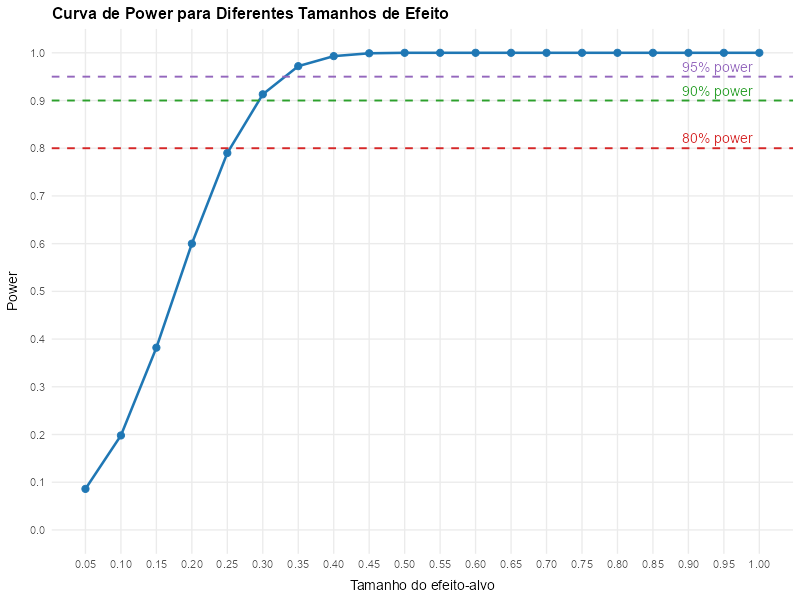

In [52]:
ggplot(power_table, aes(x = efeito, y = power)) +
  geom_line(linewidth = 1.2, color = "#1f77b4") +
  geom_point(size = 3, color = "#1f77b4") +
  
  # linhas horizontais para 80%, 90%, 95%
  geom_hline(yintercept = 0.80, linetype = "dashed", color = "#d62728", linewidth = 0.9) +
  geom_hline(yintercept = 0.90, linetype = "dashed", color = "#2ca02c", linewidth = 0.9) +
  geom_hline(yintercept = 0.95, linetype = "dashed", color = "#9467bd", linewidth = 0.9) +
  
  # etiquetas
  annotate("text", x = max(power_table$efeito), y = 0.80, 
           label = "80% power", hjust = 1.1, vjust = -0.5, color = "#d62728") +
  annotate("text", x = max(power_table$efeito), y = 0.90, 
           label = "90% power", hjust = 1.1, vjust = -0.5, color = "#2ca02c") +
  annotate("text", x = max(power_table$efeito), y = 0.95, 
           label = "95% power", hjust = 1.1, vjust = -0.5, color = "#9467bd") +
  
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
  scale_x_continuous(breaks = effects_grid) +
  
  labs(
    title = "Curva de Power para Diferentes Tamanhos de Efeito",
    x = "Tamanho do efeito-alvo",
    y = "Power"
  ) +
  
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 10)),
    panel.grid.minor = element_blank()
  )


### **Resumo da interpretação do gráfico de power**

O gráfico mostra como o **power aumenta conforme o tamanho do efeito-alvo cresce**.
Com o SE obtido no modelo TWFE, o estudo:

* atinge **80% de power** quando o efeito é por volta de **0.25**
* atinge **90% de power** quando o efeito é próximo de **0.30**
* atinge **95% de power** quando o efeito chega a **0.35–0.40**

Em outras palavras:

> **O estudo tem boa sensibilidade apenas para efeitos maiores que aproximadamente 0.25.
> Efeitos menores do que isso têm baixa probabilidade de serem detectados.**

Isso confirma a leitura do MDE:
o “tamanho mínimo visível” deste desenho é cerca de **0.25**.


-----------------------
## **Conclusão**

A análise mostrou que interpretar um resultado “não significativo” exige muito mais cuidado do que simplesmente olhar o p-valor. O erro-padrão do estimador determina diretamente o quanto o estudo é capaz de enxergar efeitos reais. Com o SE obtido no modelo TWFE, observamos que o estudo só atinge 80% de poder para detectar efeitos acima de aproximadamente 0.25. Isso significa que, caso o impacto verdadeiro fosse menor do que esse valor, o modelo teria grande chance de não identificá-lo, mesmo que ele exista.

A curva de power reforça essa leitura: à medida que o efeito-alvo cresce, o power sobe rapidamente, e efeitos moderados (0.30, 0.35, 0.40) se tornam facilmente detectáveis. Porém, efeitos pequenos permanecem abaixo do “limite de resolução” estatística do desenho.

Assim, a conclusão fundamental é:

> **Ausência de significância não é evidência de ausência de efeito.**
> Muitas vezes, o modelo simplesmente não tem poder estatístico para enxergar o impacto que se busca medir.

Em avaliações de políticas públicas, marketing e experimentos aplicados, isso significa que rejeitar uma intervenção com base apenas no p-valor pode levar a decisões equivocadas. Avaliar o poder e o MDE permite entender a sensibilidade real do estudo e evitar interpretações erradas, garantindo conclusões mais honestas, robustas e alinhadas com a magnitude dos efeitos que realmente importam.
